In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

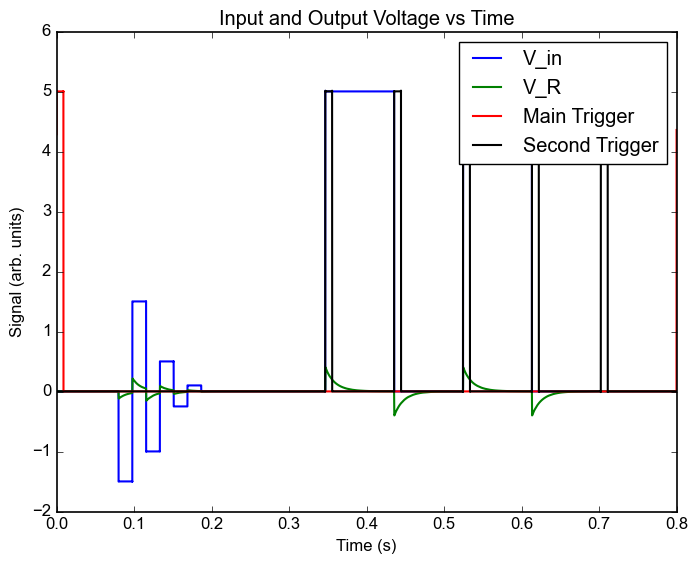

In [58]:
data1 = np.loadtxt("./Data_20262804/20262804002.dat")
data2 = np.loadtxt("./Data_20262804/20262804002.snp")
C_actual = 10e-9  # 10 nF in  (Mica 222)

R1 = 1e6
R2 = 1e5  # Resistance in ohms

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]
second_trigger = data1[:, 4]
I = data1[:, 5]


plt.plot(t, V_in, label='V_in', lw = 1.5, color = 'blue')
plt.plot(t, V_R, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()

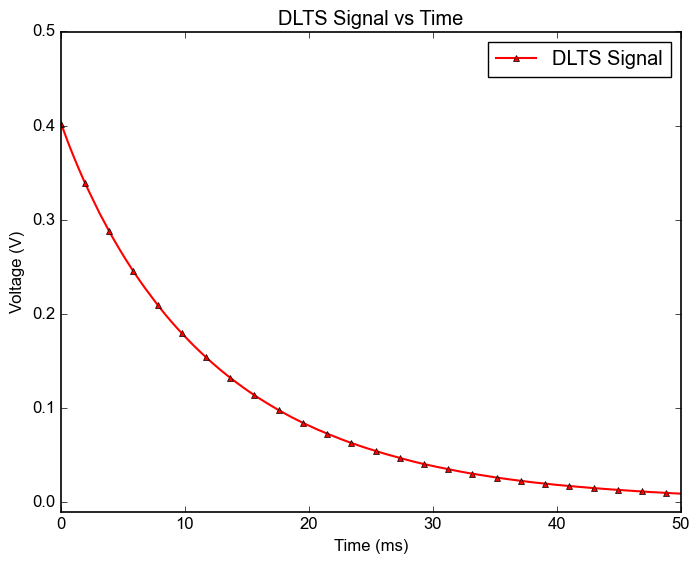

In [59]:
t = data2[:, 0]
V = data2[:, 1]

plt.plot(t*1e3, V, label='DLTS Signal', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=200)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 50)
plt.ylim(-0.01, 0.5)
plt.legend(frameon=True, numpoints=1)
plt.show()

a = 0.393 ± 9.16e-05
b = 0.0127 ± 4.14e-06
R^2 = 1.000
C (fitted) = (11.517 ± 0.004) nF
C (actual) = 10.000 nF
Difference = 15.17%


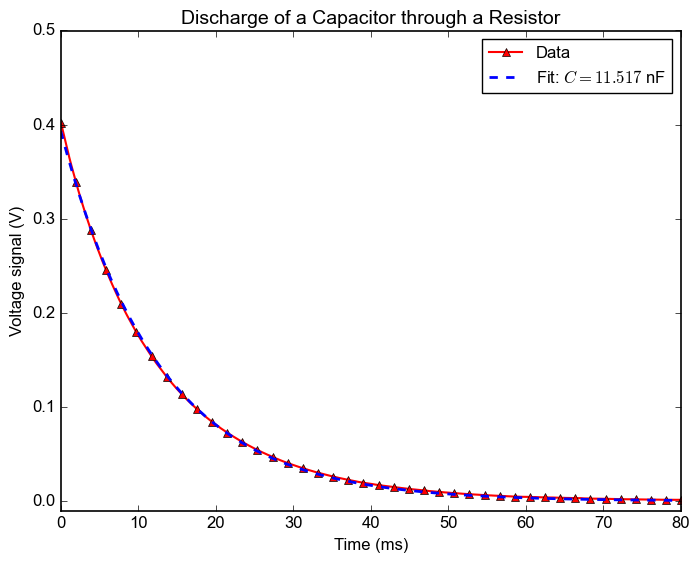

In [60]:
def func(x, a, b):
    return a * np.exp(-x / b)

# Known capacitor value (placed before fitting so we can use it as an initial guess)


# Find the rising/falling edge and fit to the decay region
# Adjust time window to capture the exponential decay (starting earlier)
mask = np.isfinite(t) & np.isfinite(V) & (t >= 0.0001) & (t <= 0.08)
# Initial guesses: a ~ peak voltage in window, b ~ C_actual*(R1+R2) (time constant)
if np.any(mask):
    a0 = np.max(V[mask])
else:
    a0 = np.max(V)
b0 = C_actual * (R1 + R2)
p0 = [a0, b0]

popt, pcov = curve_fit(func, t[mask], V[mask], p0=p0, maxfev=10000)
sigma_fit = func(t[mask], *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((V[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V[mask] - np.mean(V[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
C = b / (R1 + R2)
C_err = b_err / (R1 + R2)  

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")

print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")
print(f"C (actual) = {C_actual*1e9:.3f} nF")
print(f"Difference = {abs(C - C_actual)/C_actual * 100:.2f}%")

x = np.linspace(0.00, 0.08, 100)
plt.plot(t*1e3, V, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=200)
plt.plot(x*1e3, func(x, *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 80)
plt.ylim(-0.01, 0.5)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()